In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, LineString, Point
import numpy as np

def load_polygon_from_csv(filepath):
    """Load polygon coordinates from a CSV file."""
    data = pd.read_csv(filepath)
    latitudes = data['Latitude']
    longitudes = data['Longitude']
    coordinates = list(zip(longitudes, latitudes))
    return Polygon(coordinates)

def generate_zigzag_path(boundary, row_spacing=0.00002, offset=0.0):
    """Generate a zigzag path within a polygon boundary."""
    min_x, min_y, max_x, max_y = boundary.bounds
    waypoints = []

    x_values = np.arange(min_x + offset, max_x, row_spacing)
    for i, x in enumerate(x_values):
        line = LineString([(x, min_y), (x, max_y)])
        clipped_line = line.intersection(boundary)
        if not clipped_line.is_empty and clipped_line.geom_type == 'LineString':
            coords = list(clipped_line.coords)
            if i % 2 == 1:
                coords = coords[::-1]  # Alternate direction for zigzag
            waypoints.extend(coords)
    return waypoints

def plot_paths(boundary, paths, avoidance_polygon=None):
    """Plot the boundary, paths, and avoidance area."""
    plt.figure(figsize=(8, 8))
    
    # Plot boundary
    plt.plot(*boundary.exterior.xy, color='blue', label='Boundary')

    # Plot avoidance area if provided
    if avoidance_polygon:
        plt.plot(*avoidance_polygon.exterior.xy, color='red', label='Avoidance Area')
    
    # Plot paths
    for i, path in enumerate(paths):
        x, y = zip(*path)
        plt.plot(x, y, label=f'Path {i + 1}')
    
    plt.title("Zigzag Paths with Avoidance Area")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    plt.grid()
    plt.show()

# Example usage
boundary_file = "/home/user/abd_ws/src/tests/tests/gps_data.csv"  # Replace with the path to your main boundary CSV
avoidance_file = "/home/user/abd_ws/src/tests/tests/gps_data2.csv"  # Replace with the path to your avoidance area CSV

# Load polygons
main_boundary = load_polygon_from_csv(boundary_file)
avoidance_area = load_polygon_from_csv(avoidance_file)

# Subtract avoidance area from main boundary
modified_boundary = main_boundary.difference(avoidance_area)

# Generate zigzag paths
primary_path = generate_zigzag_path(modified_boundary)
secondary_path = generate_zigzag_path(modified_boundary, offset=0.00001)
tertiary_path = generate_zigzag_path(modified_boundary, offset=0.00002)

# Plot paths
plot_paths(modified_boundary, [primary_path, secondary_path, tertiary_path], avoidance_polygon=avoidance_area)


GEOSException: TopologyException: side location conflict at -79.383264291897433 43.65317597488793. This can occur if the input geometry is invalid.

In [5]:
def validate_geometry(geometry, name="Geometry"):
    """Check and fix invalid geometry if possible."""
    if not geometry.is_valid:
        print(f"{name} is invalid. Attempting to fix it.")
        geometry = geometry.buffer(0)  # Attempt to fix
        if not geometry.is_valid:
            raise ValueError(f"{name} is still invalid after attempting to fix it.")
    return geometry


main_boundary = validate_geometry(main_boundary, "Main Boundary")
avoidance_area = validate_geometry(avoidance_area, "Avoidance Area")

# Perform the difference operation
modified_boundary = main_boundary.difference(avoidance_area)


Avoidance polygon is invalid. Attempting to fix it.
Multiple areas detected. Selecting the largest one.


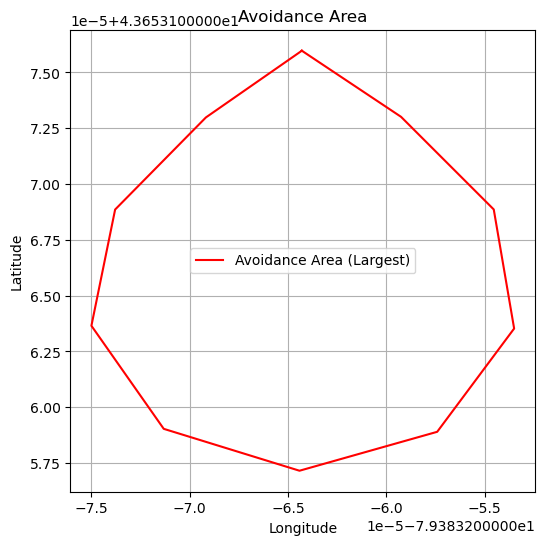

In [9]:
from shapely.geometry import MultiPolygon, Polygon
import pandas as pd
import matplotlib.pyplot as plt

def load_and_fix_avoidance_area(filepath):
    """Load coordinates from a CSV and select the largest area if multiple are formed."""
    # Load the CSV data
    data = pd.read_csv(filepath)
    latitudes = data['Latitude']
    longitudes = data['Longitude']
    coordinates = list(zip(longitudes, latitudes))
    polygon = Polygon(coordinates)

    # Check if the polygon is valid
    if not polygon.is_valid:
        print("Avoidance polygon is invalid. Attempting to fix it.")
        polygon = polygon.buffer(0)

    # Handle MultiPolygon if multiple areas are formed
    if isinstance(polygon, MultiPolygon):
        print("Multiple areas detected. Selecting the largest one.")
        polygon = max(polygon.geoms, key=lambda p: p.area)

    # Ensure the final polygon is valid
    if not polygon.is_valid:
        raise ValueError("The largest avoidance area is still invalid after fixing.")
    
    return polygon

# Example usage
avoidance_file = "/home/user/abd_ws/src/tests/tests/gps_data2.csv"  # Replace with your avoidance area CSV file
avoidance_area = load_and_fix_avoidance_area(avoidance_file)

# Plot the resulting avoidance area
plt.figure(figsize=(6, 6))
plt.plot(*avoidance_area.exterior.xy, color='red', label='Avoidance Area (Largest)')
plt.title("Avoidance Area")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid()
plt.show()


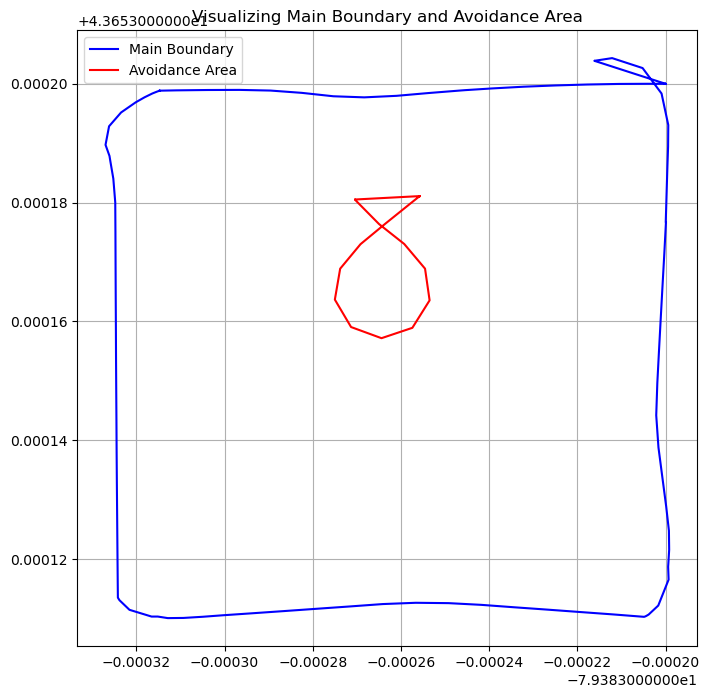

In [7]:
plt.figure(figsize=(8, 8))
plt.plot(*main_boundary.exterior.xy, color='blue', label='Main Boundary')
plt.plot(*avoidance_area.exterior.xy, color='red', label='Avoidance Area')
plt.title("Visualizing Main Boundary and Avoidance Area")
plt.legend()
plt.grid()
plt.show()


In [10]:
def handle_invalid_polygon(polygon, name="Polygon"):
    """Handle invalid polygons by extracting valid parts."""
    if not polygon.is_valid:
        print(f"{name} is invalid. Attempting to fix or extract valid parts.")
        # Attempt to fix the polygon
        fixed_polygon = polygon.buffer(0)
        
        # If it results in a MultiPolygon, extract the largest valid part
        if isinstance(fixed_polygon, MultiPolygon):
            print(f"{name} resulted in a MultiPolygon. Selecting the largest valid part.")
            fixed_polygon = max(fixed_polygon.geoms, key=lambda p: p.area)
        
        # Ensure the resulting geometry is valid
        if not fixed_polygon.is_valid:
            print(f"{name} is still invalid. Proceeding with original polygon, but results may vary.")
            return polygon  # Return original to proceed

        return fixed_polygon
    
    return polygon


In [11]:
# Handle invalid polygons
main_boundary = handle_invalid_polygon(main_boundary, "Main Boundary")
avoidance_area = handle_invalid_polygon(avoidance_area, "Avoidance Area")

# Proceed with the difference operation
modified_boundary = main_boundary.difference(avoidance_area)


Main Boundary is invalid. Attempting to fix or extract valid parts.
Main Boundary resulted in a MultiPolygon. Selecting the largest valid part.


Polygon from /home/user/abd_ws/src/tests/tests/gps_data.csv is invalid. Attempting to fix.
Multiple areas detected in /home/user/abd_ws/src/tests/tests/gps_data.csv. Selecting the largest area.
Polygon from /home/user/abd_ws/src/tests/tests/gps_data2.csv is invalid. Attempting to fix.
Multiple areas detected in /home/user/abd_ws/src/tests/tests/gps_data2.csv. Selecting the largest area.


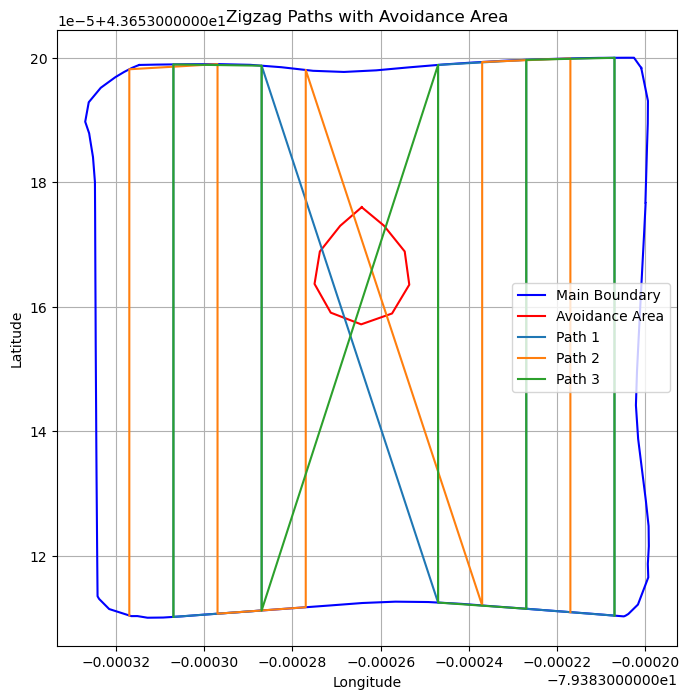

Path saved to primary_path.csv
Path saved to secondary_path.csv
Path saved to tertiary_path.csv


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPolygon, LineString, Point

def load_and_get_largest_area(filepath):
    """Load coordinates from a CSV and extract the largest valid area."""
    # Load data
    data = pd.read_csv(filepath)
    latitudes = data['Latitude']
    longitudes = data['Longitude']
    coordinates = list(zip(longitudes, latitudes))
    
    # Create a polygon from the coordinates
    polygon = Polygon(coordinates)
    
    # Handle invalid geometries
    if not polygon.is_valid:
        print(f"Polygon from {filepath} is invalid. Attempting to fix.")
        polygon = polygon.buffer(0)
    
    # If multiple areas exist, select the largest
    if isinstance(polygon, MultiPolygon):
        print(f"Multiple areas detected in {filepath}. Selecting the largest area.")
        polygon = max(polygon.geoms, key=lambda p: p.area)
    
    return polygon

def generate_zigzag_path(boundary, row_spacing=0.00002, offset=0.0):
    """Generate zigzag path within a polygon boundary."""
    min_x, min_y, max_x, max_y = boundary.bounds
    waypoints = []

    # Create zigzag lines spaced by `row_spacing`, with optional offset
    x_values = np.arange(min_x + offset, max_x, row_spacing)
    for i, x in enumerate(x_values):
        line = LineString([(x, min_y), (x, max_y)])
        clipped_line = line.intersection(boundary)
        if not clipped_line.is_empty and clipped_line.geom_type == 'LineString':
            coords = list(clipped_line.coords)
            if i % 2 == 1:
                coords = coords[::-1]  # Alternate direction for zigzag
            waypoints.extend(coords)

    return waypoints

def plot_boundary_and_paths(boundary, paths, avoidance_area=None):
    """Plot the main boundary, avoidance area, and zigzag paths."""
    plt.figure(figsize=(8, 8))
    
    # Plot main boundary
    plt.plot(*boundary.exterior.xy, color='blue', label='Main Boundary')

    # Plot avoidance area if provided
    if avoidance_area:
        plt.plot(*avoidance_area.exterior.xy, color='red', label='Avoidance Area')

    # Plot paths
    for i, path in enumerate(paths):
        x, y = zip(*path)
        plt.plot(x, y, label=f'Path {i + 1}')

    plt.title("Zigzag Paths with Avoidance Area")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    plt.grid()
    plt.show()

# File paths for main boundary and avoidance area
main_boundary_file = "/home/user/abd_ws/src/tests/tests/gps_data.csv" # Replace with your main boundary file path
avoidance_area_file = "/home/user/abd_ws/src/tests/tests/gps_data2.csv"  # Replace with your avoidance area file path


# Load and extract the largest areas
main_boundary = load_and_get_largest_area(main_boundary_file)
avoidance_area = load_and_get_largest_area(avoidance_area_file)

# Subtract avoidance area from the main boundary
try:
    modified_boundary = main_boundary.difference(avoidance_area)
    if modified_boundary.is_empty or not modified_boundary.is_valid:
        print("Modified boundary is invalid or empty. Using main boundary directly.")
        modified_boundary = main_boundary
except Exception as e:
    print(f"Error during difference operation: {e}. Using main boundary directly.")
    modified_boundary = main_boundary

# Generate paths
primary_path = generate_zigzag_path(modified_boundary)
secondary_path = generate_zigzag_path(modified_boundary, offset=0.00001)
tertiary_path = generate_zigzag_path(modified_boundary, offset=0.00002)

# Plot the results
plot_boundary_and_paths(modified_boundary, [primary_path, secondary_path, tertiary_path], avoidance_area)

# Save the paths as CSV
for path, filename in zip([primary_path, secondary_path, tertiary_path], 
                          ["primary_path.csv", "secondary_path.csv", "tertiary_path.csv"]):
    df = pd.DataFrame(path, columns=["Longitude", "Latitude"])
    df.to_csv(filename, index=False)
    print(f"Path saved to {filename}")



Polygon from /home/user/abd_ws/src/tests/tests/gps_data.csv is invalid. Attempting to fix.
Multiple areas detected in /home/user/abd_ws/src/tests/tests/gps_data.csv. Selecting the largest area.
Polygon from /home/user/abd_ws/src/tests/tests/gps_data2.csv is invalid. Attempting to fix.
Multiple areas detected in /home/user/abd_ws/src/tests/tests/gps_data2.csv. Selecting the largest area.


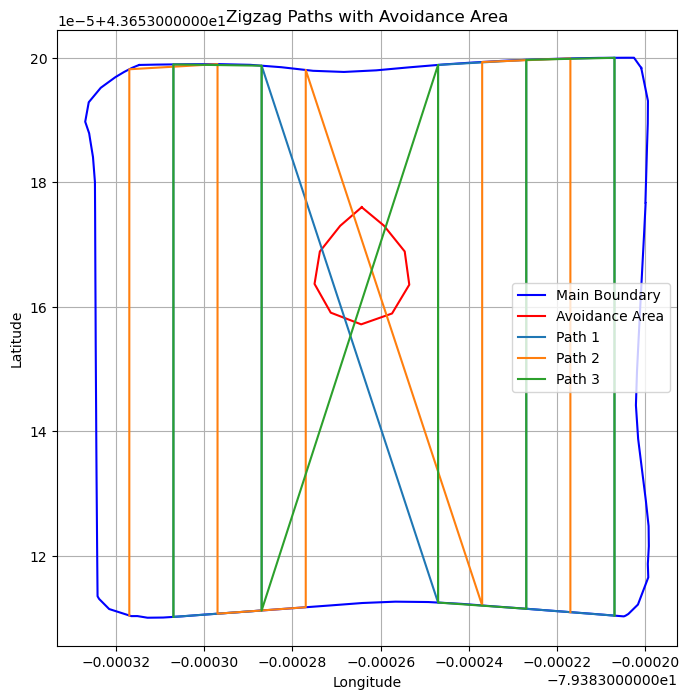

Path saved to primary_path.csv
Path saved to secondary_path.csv
Path saved to tertiary_path.csv


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPolygon, LineString, Point

def load_and_get_largest_area(filepath):
    """Load coordinates from a CSV and extract the largest valid area."""
    # Load data
    data = pd.read_csv(filepath)
    latitudes = data['Latitude']
    longitudes = data['Longitude']
    coordinates = list(zip(longitudes, latitudes))
    
    # Create a polygon from the coordinates
    polygon = Polygon(coordinates)
    
    # Handle invalid geometries
    if not polygon.is_valid:
        print(f"Polygon from {filepath} is invalid. Attempting to fix.")
        polygon = polygon.buffer(0)
    
    # If multiple areas exist, select the largest
    if isinstance(polygon, MultiPolygon):
        print(f"Multiple areas detected in {filepath}. Selecting the largest area.")
        polygon = max(polygon.geoms, key=lambda p: p.area)
    
    return polygon

def generate_zigzag_path(boundary, avoidance_area, row_spacing=0.00002, offset=0.0):
    """Generate zigzag path within a polygon boundary, avoiding a specific area."""
    min_x, min_y, max_x, max_y = boundary.bounds
    waypoints = []

    # Create zigzag lines spaced by `row_spacing`, with optional offset
    x_values = np.arange(min_x + offset, max_x, row_spacing)
    for i, x in enumerate(x_values):
        line = LineString([(x, min_y), (x, max_y)])
        clipped_line = line.intersection(boundary)

        if not clipped_line.is_empty and clipped_line.geom_type == 'LineString':
            coords = list(clipped_line.coords)
            filtered_coords = []

            # Filter out points that intersect the avoidance area
            for coord in coords:
                point = Point(coord)
                if not avoidance_area.contains(point):
                    filtered_coords.append(coord)

            if i % 2 == 1:
                filtered_coords = filtered_coords[::-1]  # Alternate direction for zigzag

            waypoints.extend(filtered_coords)

    return waypoints

def plot_boundary_and_paths(boundary, paths, avoidance_area=None):
    """Plot the main boundary, avoidance area, and zigzag paths."""
    plt.figure(figsize=(8, 8))
    
    # Plot main boundary
    plt.plot(*boundary.exterior.xy, color='blue', label='Main Boundary')

    # Plot avoidance area if provided
    if avoidance_area:
        plt.plot(*avoidance_area.exterior.xy, color='red', label='Avoidance Area')

    # Plot paths
    for i, path in enumerate(paths):
        x, y = zip(*path)
        plt.plot(x, y, label=f'Path {i + 1}')

    plt.title("Zigzag Paths with Avoidance Area")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    plt.grid()
    plt.show()


# File paths for main boundary and avoidance area
main_boundary_file = "/home/user/abd_ws/src/tests/tests/gps_data.csv" # Replace with your main boundary file path
avoidance_area_file = "/home/user/abd_ws/src/tests/tests/gps_data2.csv"  # Replace with your avoidance area file path



# Load and extract the largest areas
main_boundary = load_and_get_largest_area(main_boundary_file)
avoidance_area = load_and_get_largest_area(avoidance_area_file)

# Subtract avoidance area from the main boundary
try:
    modified_boundary = main_boundary.difference(avoidance_area)
    if modified_boundary.is_empty or not modified_boundary.is_valid:
        print("Modified boundary is invalid or empty. Using main boundary directly.")
        modified_boundary = main_boundary
except Exception as e:
    print(f"Error during difference operation: {e}. Using main boundary directly.")
    modified_boundary = main_boundary

# Generate paths avoiding the avoidance area
primary_path = generate_zigzag_path(modified_boundary, avoidance_area)
secondary_path = generate_zigzag_path(modified_boundary, avoidance_area, offset=0.00001)
tertiary_path = generate_zigzag_path(modified_boundary, avoidance_area, offset=0.00002)

# Plot the results
plot_boundary_and_paths(modified_boundary, [primary_path, secondary_path, tertiary_path], avoidance_area)

# Save the paths as CSV
for path, filename in zip([primary_path, secondary_path, tertiary_path], 
                          ["primary_path.csv", "secondary_path.csv", "tertiary_path.csv"]):
    df = pd.DataFrame(path, columns=["Longitude", "Latitude"])
    df.to_csv(filename, index=False)
    print(f"Path saved to {filename}")
